In [85]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [86]:
df = pd.read_csv("Electric_Vehicle_Population_Data (2).csv")
df.columns = df.columns.str.strip()
df.head()


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [87]:
df.shape
df.columns
df.describe()
df.isnull().sum()

VIN (1-10)                                             0
County                                                24
City                                                  24
State                                                  0
Postal Code                                           24
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        11
Legislative District                                 700
DOL Vehicle ID                                         0
Vehicle Location                                     109
Electric Utility                                      24
2020 Census Tract                                     24
dtype: int64

In [88]:
categorical_missing_cols = [
    "County",
    "City",
    "Postal Code",
    "Electric Utility"
]

for col in categorical_missing_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

if "Electric Range" in df.columns:
    df["Electric Range"] = df["Electric Range"].fillna(df["Electric Range"].median())

cols_to_drop = [
    "Legislative District",
    "Vehicle Location",
    "2020 Census Tract"
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

features = ["Model Year", "Make", "County", "State"]
target = "Electric Vehicle Type"

X = df[features]
y = df[target]

print(df.isnull().sum())
print(X.columns.tolist())


VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
DOL Vehicle ID                                       0
Electric Utility                                     0
dtype: int64
['Model Year', 'Make', 'County', 'State']


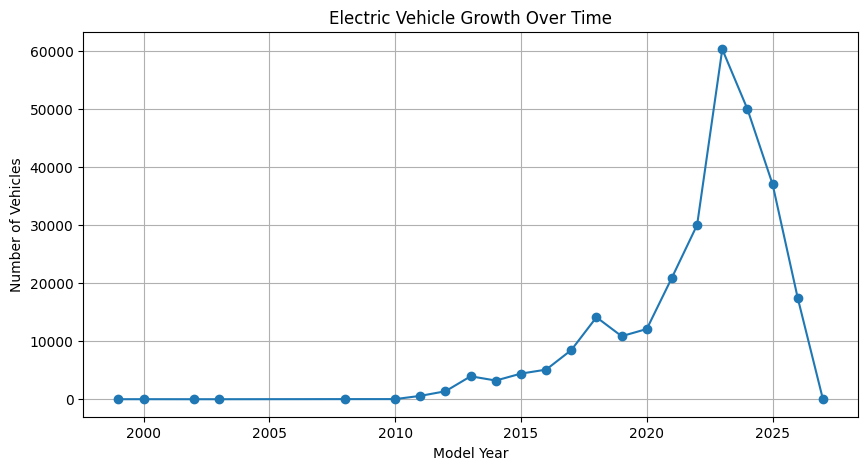

In [89]:
ev_growth = df["Model Year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(ev_growth.index, ev_growth.values, marker="o")
plt.title("Electric Vehicle Growth Over Time")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.grid(True)
plt.show()

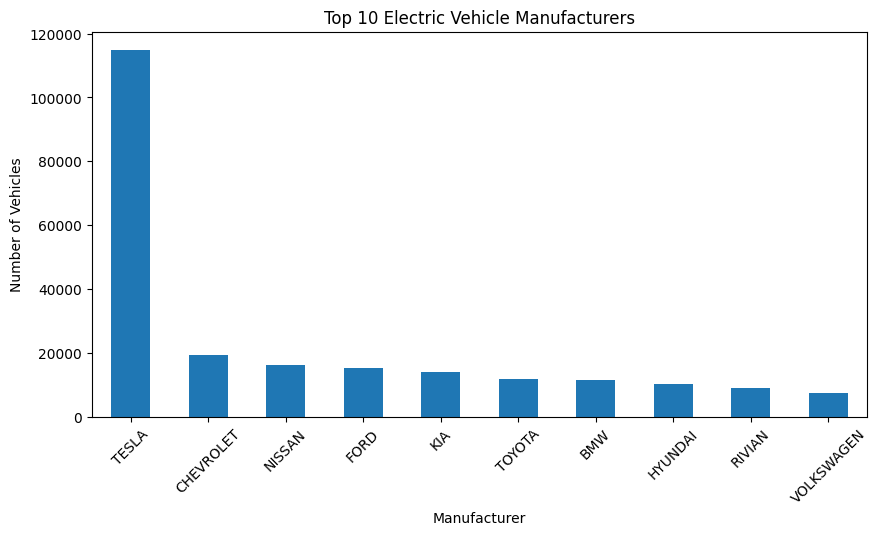

In [90]:
top_makes = df["Make"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_makes.plot(kind="bar")
plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

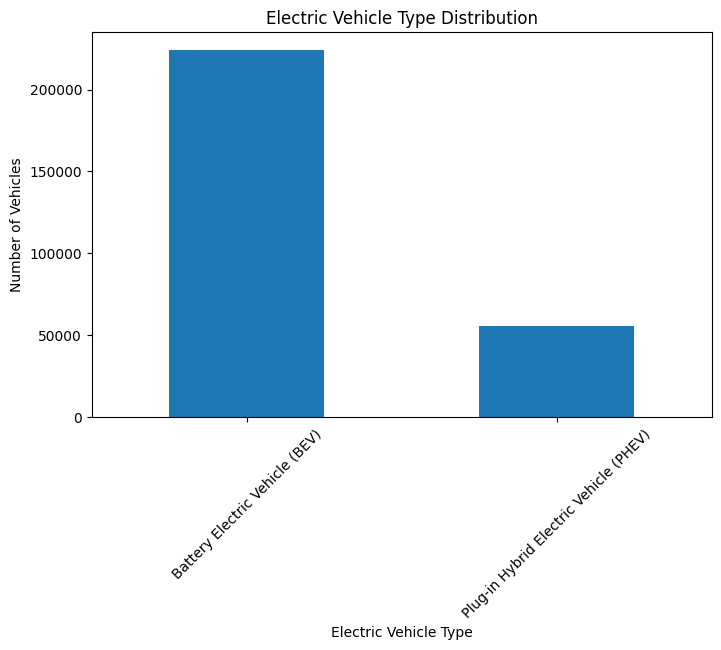

In [91]:
ev_type_counts = df["Electric Vehicle Type"].value_counts()

plt.figure(figsize=(8, 5))
ev_type_counts.plot(kind="bar")
plt.title("Electric Vehicle Type Distribution")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [93]:
numeric_features = ["Model Year"]
categorical_features = ["Make", "County", "State"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [94]:
print("X columns:", X.columns.tolist())
print("X_train columns:", X_train.columns.tolist())

X columns: ['Model Year', 'Make', 'County', 'State']
X_train columns: ['Model Year', 'Make', 'County', 'State']


In [95]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("\nBaseline Classification Report:")
print(classification_report(y_test, baseline_pred, zero_division=0))
print("\nBaseline Confusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

Baseline Accuracy: 0.8002180284509257

Baseline Classification Report:
                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.80      1.00      0.89     44777
Plug-in Hybrid Electric Vehicle (PHEV)       0.00      0.00      0.00     11179

                              accuracy                           0.80     55956
                             macro avg       0.40      0.50      0.44     55956
                          weighted avg       0.64      0.80      0.71     55956


Baseline Confusion Matrix:
[[44777     0]
 [11179     0]]


In [96]:
balanced_log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=500,
            solver="liblinear",
            class_weight="balanced"
        ))
    ]
)

balanced_log_reg_model.fit(X_train, y_train)
balanced_log_reg_pred = balanced_log_reg_model.predict(X_test)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, balanced_log_reg_pred))
print("\nBalanced Logistic Regression Classification Report:")
print(classification_report(y_test, balanced_log_reg_pred))
print("\nBalanced Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, balanced_log_reg_pred))

Balanced Logistic Regression Accuracy: 0.8844806633783687

Balanced Logistic Regression Classification Report:
                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.98      0.87      0.92     44777
Plug-in Hybrid Electric Vehicle (PHEV)       0.64      0.94      0.76     11179

                              accuracy                           0.88     55956
                             macro avg       0.81      0.90      0.84     55956
                          weighted avg       0.92      0.88      0.89     55956


Balanced Logistic Regression Confusion Matrix:
[[39004  5773]
 [  691 10488]]


In [97]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9323575666595182

Random Forest Classification Report:
                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.95      0.97      0.96     44777
Plug-in Hybrid Electric Vehicle (PHEV)       0.85      0.80      0.82     11179

                              accuracy                           0.93     55956
                             macro avg       0.90      0.88      0.89     55956
                          weighted avg       0.93      0.93      0.93     55956


Random Forest Confusion Matrix:
[[43254  1523]
 [ 2262  8917]]


In [98]:
balanced_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

balanced_rf_model.fit(X_train, y_train)
balanced_rf_pred = balanced_rf_model.predict(X_test)

print("Balanced Random Forest Accuracy:", accuracy_score(y_test, balanced_rf_pred))
print("\nBalanced Random Forest Classification Report:")
print(classification_report(y_test, balanced_rf_pred))
print("\nBalanced Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, balanced_rf_pred))

Balanced Random Forest Accuracy: 0.9097683894488526

Balanced Random Forest Classification Report:
                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.98      0.90      0.94     44777
Plug-in Hybrid Electric Vehicle (PHEV)       0.71      0.94      0.81     11179

                              accuracy                           0.91     55956
                             macro avg       0.84      0.92      0.87     55956
                          weighted avg       0.93      0.91      0.91     55956


Balanced Random Forest Confusion Matrix:
[[40426  4351]
 [  698 10481]]


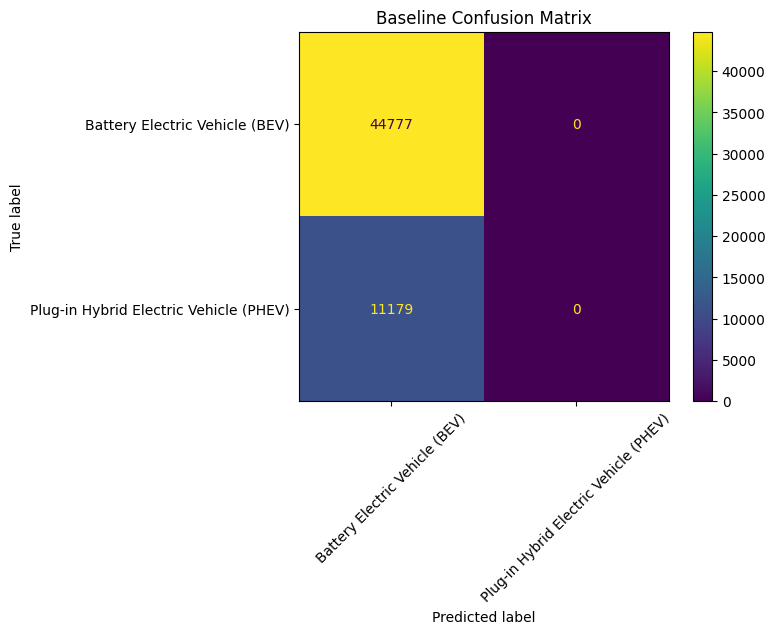

NameError: name 'log_reg_pred' is not defined

In [99]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred)
plt.title("Baseline Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, log_reg_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, balanced_log_reg_pred)
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, balanced_rf_pred)
plt.title("Balanced Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

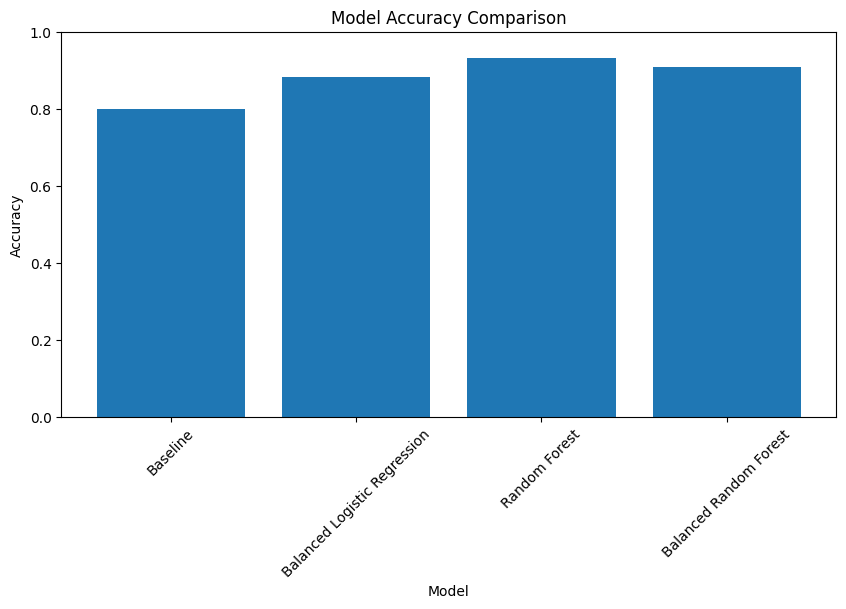

In [102]:
model_names = [
    "Baseline",
    "Balanced Logistic Regression",
    "Random Forest",
    "Balanced Random Forest"
]

accuracies = [
    accuracy_score(y_test, baseline_pred),
    accuracy_score(y_test, balanced_log_reg_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, balanced_rf_pred)
]

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

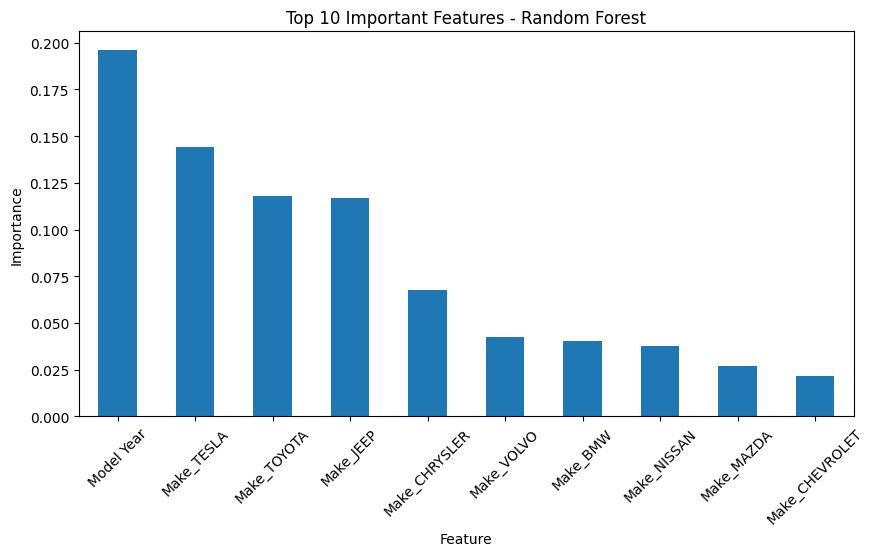

Model Year        0.196198
Make_TESLA        0.144088
Make_TOYOTA       0.118027
Make_JEEP         0.117010
Make_CHRYSLER     0.067424
Make_VOLVO        0.042604
Make_BMW          0.040519
Make_NISSAN       0.037620
Make_MAZDA        0.026932
Make_CHEVROLET    0.021878
dtype: float64

In [103]:
rf_classifier = rf_model.named_steps["classifier"]
onehot = rf_model.named_steps["preprocessor"].named_transformers_["cat"]

encoded_feature_names = onehot.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_feature_names)

feature_importances = pd.Series(
    rf_classifier.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

top_10_features = feature_importances.head(10)

plt.figure(figsize=(10, 5))
top_10_features.plot(kind="bar")
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

top_10_features

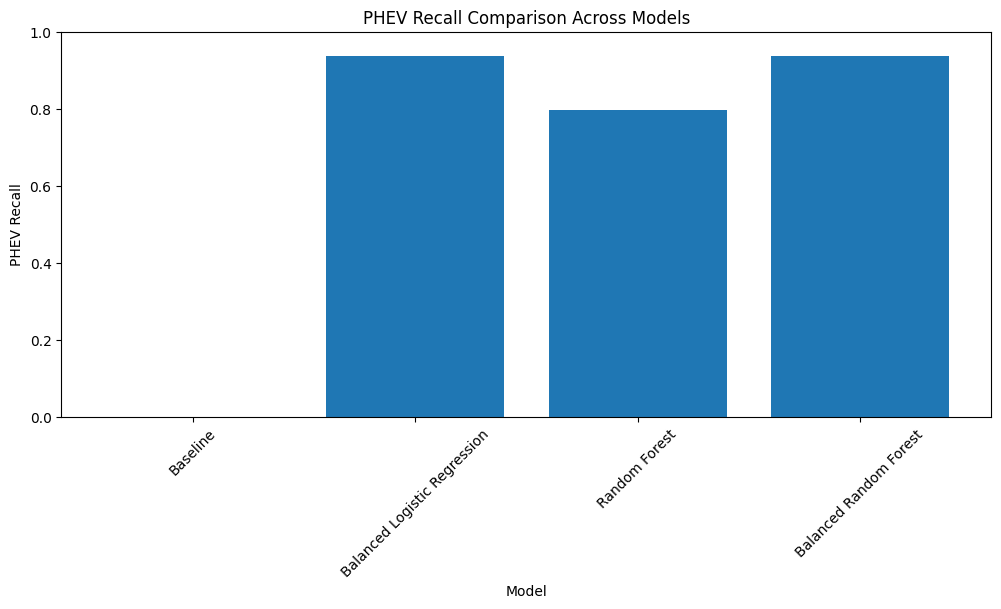

In [105]:
from sklearn.metrics import recall_score

positive_class = "Plug-in Hybrid Electric Vehicle (PHEV)"

phev_recalls = [
    recall_score(y_test, baseline_pred, pos_label=positive_class),
    recall_score(y_test, balanced_log_reg_pred, pos_label=positive_class),
    recall_score(y_test, rf_pred, pos_label=positive_class),
    recall_score(y_test, balanced_rf_pred, pos_label=positive_class)
]

plt.figure(figsize=(12, 5))
plt.bar(model_names, phev_recalls)
plt.title("PHEV Recall Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("PHEV Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [106]:
df.to_csv("cleaned_ev_population_data.csv", index=False)